# Evaluación probabilística

La comparación se hace contra dos referencias:

- **Mercado:** probabilidades implícitas en las cuotas de las casas.
- **Baseline uniforme:** asigna la misma probabilidad a cada resultado y representa una predicción sin información.

Se revisan dos mercados por separado:

1. **1X2:** victoria local, empate o victoria visitante.
2. **Over/Under 2.5:** tres goles o más frente a dos goles o menos.

Todas las métricas utilizadas se interpretan igual: **un valor menor indica una mejor predicción probabilística**.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import log_loss

warnings.filterwarnings("ignore", category=UserWarning)

BLUE = "#2563EB"
BLUE_LIGHT = "#BFDBFE"
GOLD = "#D89B19"
GOLD_LIGHT = "#FDE7A9"
INK = "#1F2937"
MUTED = "#6B7280"
GRID = "#E5E7EB"
PAPER = "#FCFCFA"
GREY = "#9CA3AF"
GREY_LIGHT = "#EEF0F3"

plt.rcParams.update({
    "figure.facecolor": PAPER,
    "axes.facecolor": PAPER,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 11.5,
    "axes.titleweight": "bold",
})


def clean_axes(ax, grid_axis="x", keep_left=True, keep_bottom=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(keep_left)
    ax.spines["bottom"].set_visible(keep_bottom)
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)


def finish_chart(fig, subtitle, y=0.90):
    fig.text(0.06, y, subtitle, fontsize=10.3, color=MUTED, ha="left")


data_candidates = [Path("../02_data"), Path("02_data")]
DATA_DIR = next((path for path in data_candidates if path.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("No se encontró la carpeta 02_data")

SOURCE_PATH = DATA_DIR / "predictions.xlsx"
raw_predictions = pd.read_excel(SOURCE_PATH)

context_columns = ["match_id", "match_date", "league", "home_goals", "away_goals"]
model_1x2_odds = ["home_odds", "draw_odds", "away_odds"]
market_1x2_odds = ["market_home_odds", "market_draw_odds", "market_away_odds"]
model_totals_odds = ["under_25_odds", "over_25_odds"]
market_totals_odds = ["market_under_25_odds", "market_over_25_odds"]
required_columns = (
    context_columns
    + model_1x2_odds
    + market_1x2_odds
    + model_totals_odds
    + market_totals_odds
)

missing_columns = set(required_columns) - set(raw_predictions.columns)
assert not missing_columns, f"Faltan columnas requeridas: {sorted(missing_columns)}"

raw_predictions["match_date"] = pd.to_datetime(raw_predictions["match_date"])
assert raw_predictions["match_id"].is_unique
assert (raw_predictions[["home_goals", "away_goals"]] >= 0).all().all()

one_x_two_columns = context_columns + model_1x2_odds + market_1x2_odds
totals_columns = context_columns + model_totals_odds + market_totals_odds

one_x_two_matches = raw_predictions[one_x_two_columns].dropna().copy()
totals_matches = raw_predictions[totals_columns].dropna().copy()

assert (one_x_two_matches[model_1x2_odds + market_1x2_odds] > 0).all().all()
assert (totals_matches[model_totals_odds + market_totals_odds] > 0).all().all()

coverage = pd.DataFrame({
    "Indicador": [
        "Archivo fuente",
        "Partidos en el archivo",
        "Muestra 1X2",
        "Muestra Over/Under 2.5",
        "Exclusiones Over/Under",
        "Ligas",
        "Periodo",
    ],
    "Valor": [
        SOURCE_PATH.as_posix(),
        f"{len(raw_predictions):,}",
        f"{len(one_x_two_matches):,}",
        f"{len(totals_matches):,}",
        f"{len(raw_predictions) - len(totals_matches):,}",
        f"{raw_predictions['league'].nunique():,}",
        f"{raw_predictions['match_date'].min():%d/%m/%Y} – {raw_predictions['match_date'].max():%d/%m/%Y}",
    ],
})

display(coverage.set_index("Indicador"))

,Valor
Indicador,
Archivo fuente,../02_data/predictions.xlsx
Partidos en el archivo,485
Muestra 1X2,485
Muestra Over/Under 2.5,478
Exclusiones Over/Under,7
Ligas,8
Periodo,03/01/2025 – 27/04/2025


## De cuotas a probabilidades y métricas

- **Log Loss:** penaliza especialmente las predicciones muy seguras que terminan siendo incorrectas.
- **ECE:** resume la distancia entre probabilidad predicha y frecuencia observada en diez intervalos.

Las magnitudes de estas métricas no son comparables entre sí. Cada una debe leerse contra el mercado y contra su propio baseline.

In [2]:
def odds_to_probabilities(frame, odds_columns):
    implied = 1 / frame[odds_columns].to_numpy(dtype=float)
    return implied / implied.sum(axis=1, keepdims=True)


model_1x2_probs = odds_to_probabilities(one_x_two_matches, model_1x2_odds)
market_1x2_probs = odds_to_probabilities(one_x_two_matches, market_1x2_odds)

model_totals_probs = odds_to_probabilities(totals_matches, model_totals_odds)
market_totals_probs = odds_to_probabilities(totals_matches, market_totals_odds)

actual_1x2 = np.select(
    [
        one_x_two_matches["home_goals"] > one_x_two_matches["away_goals"],
        one_x_two_matches["home_goals"] == one_x_two_matches["away_goals"],
    ],
    [0, 1],
    default=2,
).astype(int)

actual_over_25 = (
    totals_matches["home_goals"] + totals_matches["away_goals"] > 2.5
).astype(int).to_numpy()

for probability_matrix in [
    model_1x2_probs,
    market_1x2_probs,
    model_totals_probs,
    market_totals_probs,
]:
    assert np.isfinite(probability_matrix).all()
    assert (probability_matrix >= 0).all()
    assert (probability_matrix <= 1).all()
    assert np.allclose(probability_matrix.sum(axis=1), 1)

assert set(np.unique(actual_1x2)) == {0, 1, 2}
assert set(np.unique(actual_over_25)) == {0, 1}

In [3]:
uniform_1x2_probs = np.full_like(model_1x2_probs, 1 / 3)
uniform_totals_probs = np.full_like(model_totals_probs, 1 / 2)

metrics_1x2 = pd.DataFrame(
    {
        "Modelo": [
            log_loss(actual_1x2, model_1x2_probs, labels=[0, 1, 2]),
        ],
        "Mercado": [
            log_loss(actual_1x2, market_1x2_probs, labels=[0, 1, 2]),
        ],
        "Baseline uniforme": [
            log_loss(actual_1x2, uniform_1x2_probs, labels=[0, 1, 2]),
        ],
    },
    index=["Log Loss"],
)

metrics_totals = pd.DataFrame(
    {
        "Modelo": [
            log_loss(actual_over_25, model_totals_probs, labels=[0, 1]),
        ],
        "Mercado": [
            log_loss(actual_over_25, market_totals_probs, labels=[0, 1]),
        ],
        "Baseline uniforme": [
            log_loss(actual_over_25, uniform_totals_probs, labels=[0, 1]),
        ],
    },
    index=["Log Loss"],
)

## Resultados 1X2

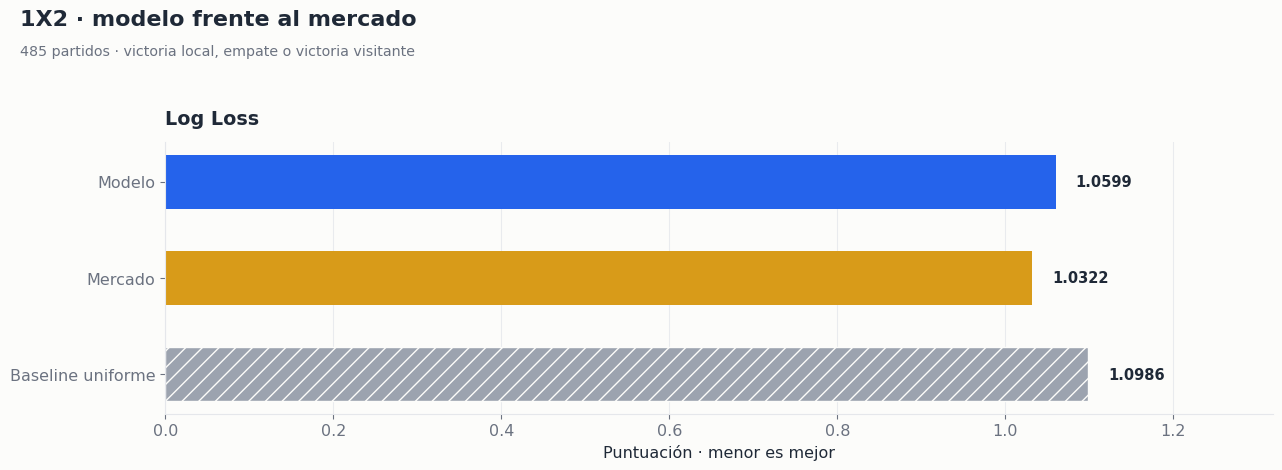

In [4]:
def plot_score_comparison(results, title, subtitle):
    fig, axes = plt.subplots(1, len(results.index), figsize=(13.8, 4.8))

    source_order = ["Baseline uniforme", "Mercado", "Modelo"]
    color_map = {
        "Modelo": BLUE,
        "Mercado": GOLD,
        "Baseline uniforme": GREY,
    }

    for ax, metric in zip(np.atleast_1d(axes), results.index):
        values = results.loc[metric, source_order]
        bars = ax.barh(
            source_order,
            values,
            color=[color_map[source] for source in source_order],
            height=0.56,
        )
        bars[0].set_hatch("//")
        bars[0].set_edgecolor(PAPER)

        axis_max = values.max() * 1.20
        ax.set_xlim(0, axis_max)
        ax.set_title(metric, loc="left", pad=13)
        ax.set_xlabel("Puntuación · menor es mejor")
        clean_axes(ax, grid_axis="x")

        for bar, value in zip(bars, values):
            ax.text(
                value + axis_max * 0.018,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.4f}",
                va="center",
                fontweight="bold",
                fontsize=10.5,
            )

    fig.suptitle(title, x=0.06, y=0.995, ha="left", fontsize=16, fontweight="bold")
    finish_chart(fig, subtitle)
    fig.tight_layout(rect=[0.04, 0.02, 0.98, 0.90])
    plt.show()


plot_score_comparison(
    metrics_1x2,
    "1X2 · modelo frente al mercado",
    f"{len(one_x_two_matches):,} partidos · victoria local, empate o victoria visitante",
)

## Resultados Over/Under 2.5

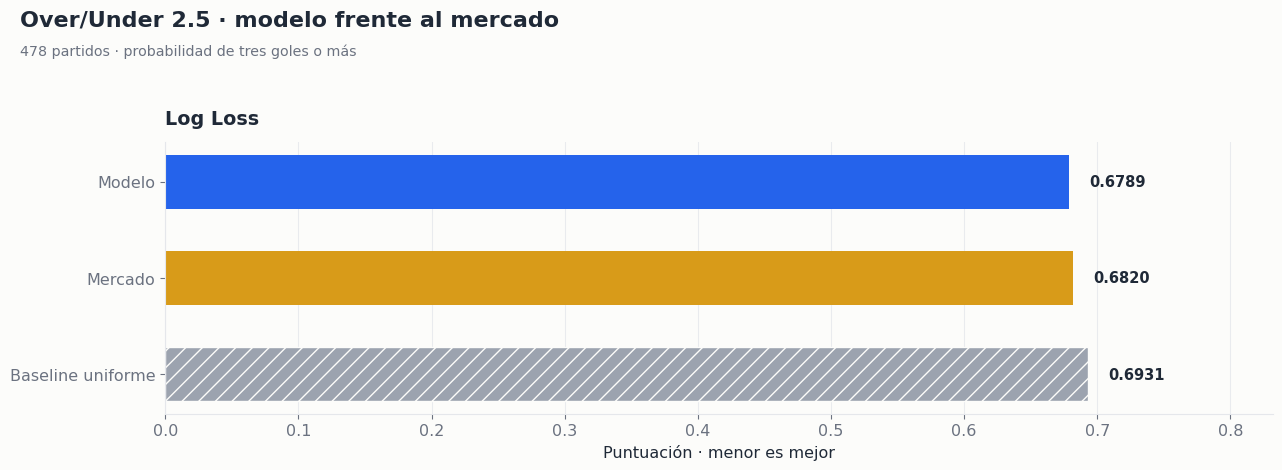

In [5]:
plot_score_comparison(
    metrics_totals,
    "Over/Under 2.5 · modelo frente al mercado",
    f"{len(totals_matches):,} partidos · probabilidad de tres goles o más",
)

## ¿Las probabilidades están calibradas?

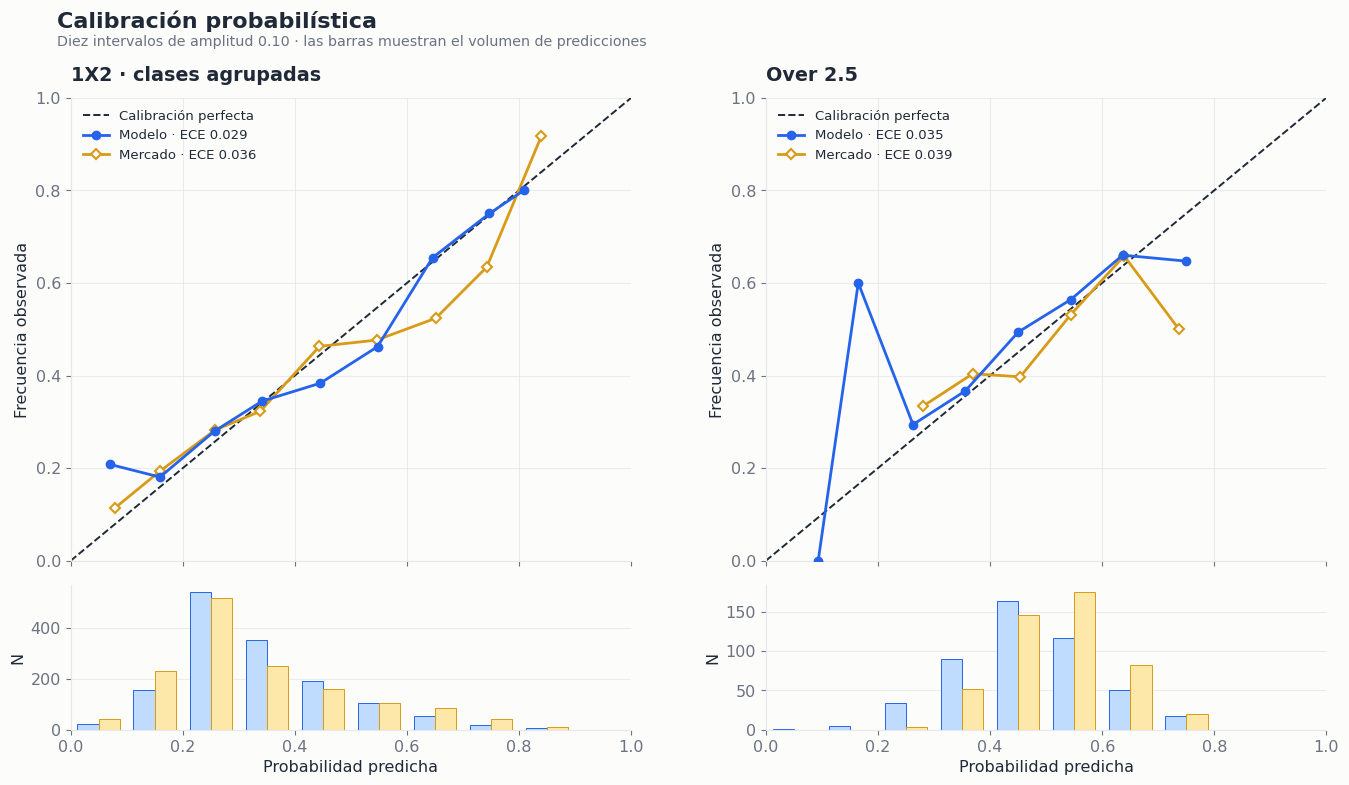

In [12]:
def compute_calibration(y_true, predicted_probability, n_bins=10):
    y_true = np.asarray(y_true, dtype=float)
    predicted_probability = np.asarray(predicted_probability, dtype=float)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_index = np.digitize(predicted_probability, bin_edges[1:-1])

    rows = []
    for index in range(n_bins):
        in_bin = bin_index == index
        count = int(in_bin.sum())
        rows.append({
            "bin": index,
            "bin_center": (bin_edges[index] + bin_edges[index + 1]) / 2,
            "mean_probability": predicted_probability[in_bin].mean() if count else np.nan,
            "observed_frequency": y_true[in_bin].mean() if count else np.nan,
            "count": count,
        })

    calibration = pd.DataFrame(rows)
    populated = calibration["count"] > 0
    ece = (
        calibration.loc[populated, "count"]
        * (
            calibration.loc[populated, "observed_frequency"]
            - calibration.loc[populated, "mean_probability"]
        ).abs()
    ).sum() / calibration["count"].sum()

    return calibration, float(ece)


one_x_two_indicators = np.eye(3)[actual_1x2].ravel()

calibration_model_1x2, ece_model_1x2 = compute_calibration(
    one_x_two_indicators, model_1x2_probs.ravel()
)
calibration_market_1x2, ece_market_1x2 = compute_calibration(
    one_x_two_indicators, market_1x2_probs.ravel()
)
calibration_model_totals, ece_model_totals = compute_calibration(
    actual_over_25, model_totals_probs[:, 1]
)
calibration_market_totals, ece_market_totals = compute_calibration(
    actual_over_25, market_totals_probs[:, 1]
)


def plot_calibration_panel(
    curve_ax,
    volume_ax,
    model_calibration,
    market_calibration,
    model_ece,
    market_ece,
    title,
):
    model_valid = model_calibration["count"] > 0
    market_valid = market_calibration["count"] > 0

    curve_ax.plot(
        [0, 1],
        [0, 1],
        color=INK,
        linestyle="--",
        linewidth=1.4,
        label="Calibración perfecta",
        zorder=1,
    )
    curve_ax.plot(
        model_calibration.loc[model_valid, "mean_probability"],
        model_calibration.loc[model_valid, "observed_frequency"],
        color=BLUE,
        marker="o",
        linewidth=2,
        markersize=6,
        label=f"Modelo · ECE {model_ece:.3f}",
        zorder=3,
    )
    curve_ax.plot(
        market_calibration.loc[market_valid, "mean_probability"],
        market_calibration.loc[market_valid, "observed_frequency"],
        color=GOLD,
        marker="D",
        markerfacecolor=PAPER,
        markeredgewidth=1.5,
        linewidth=2,
        markersize=5.5,
        label=f"Mercado · ECE {market_ece:.3f}",
        zorder=2,
    )

    curve_ax.set_xlim(0, 1)
    curve_ax.set_ylim(0, 1)
    curve_ax.set_title(title, loc="left", pad=12)
    curve_ax.set_ylabel("Frecuencia observada")
    curve_ax.legend(loc="upper left", frameon=False, fontsize=9.5)
    clean_axes(curve_ax, grid_axis="both")

    centers = model_calibration["bin_center"].to_numpy()
    width = 0.038
    volume_ax.bar(
        centers - width / 2,
        model_calibration["count"],
        width=width,
        color=BLUE_LIGHT,
        edgecolor=BLUE,
        linewidth=0.7,
        label="Modelo",
    )
    volume_ax.bar(
        centers + width / 2,
        market_calibration["count"],
        width=width,
        color=GOLD_LIGHT,
        edgecolor=GOLD,
        linewidth=0.7,
        label="Mercado",
    )
    volume_ax.set_xlim(0, 1)
    volume_ax.set_xlabel("Probabilidad predicha")
    volume_ax.set_ylabel("N")
    clean_axes(volume_ax, grid_axis="y")


fig = plt.figure(figsize=(13.8, 8.0))
grid = fig.add_gridspec(2, 2, height_ratios=[3.2, 1.0], hspace=0.08, wspace=0.24)

ax_curve_1x2 = fig.add_subplot(grid[0, 0])
ax_volume_1x2 = fig.add_subplot(grid[1, 0], sharex=ax_curve_1x2)
ax_curve_totals = fig.add_subplot(grid[0, 1])
ax_volume_totals = fig.add_subplot(grid[1, 1], sharex=ax_curve_totals)

plot_calibration_panel(
    ax_curve_1x2,
    ax_volume_1x2,
    calibration_model_1x2,
    calibration_market_1x2,
    ece_model_1x2,
    ece_market_1x2,
    "1X2 · clases agrupadas",
)
plot_calibration_panel(
    ax_curve_totals,
    ax_volume_totals,
    calibration_model_totals,
    calibration_market_totals,
    ece_model_totals,
    ece_market_totals,
    "Over 2.5",
)

ax_curve_1x2.tick_params(labelbottom=False)
ax_curve_totals.tick_params(labelbottom=False)

fig.suptitle(
    "Calibración probabilística",
    x=0.06,
    y=0.99,
    ha="left",
    fontsize=16,
    fontweight="bold",
)
finish_chart(
    fig,
    "Diez intervalos de amplitud 0.10 · las barras muestran el volumen de predicciones",
    y=0.945
)
fig.subplots_adjust(left=0.07, right=0.98, bottom=0.09, top=0.88)
plt.show()

## Qué nos llevamos

- En 1X2, el mercado obtiene mejores resultados en Log Loss.
- En Over/Under 2.5, el modelo mantiene una ventaja pequeña sobre el mercado en Log Loss.
- El ECE agregado favorece al modelo en ambos mercados, aunque la calibración por sí sola no determina cuál sistema asigna mejor probabilidad al resultado exacto.
- Las conclusiones describen esta muestra histórica; no prueban que las diferencias pequeñas se mantengan fuera de ella.

## Checks de reproducibilidad

- Fuente congelada: `02_data/predictions.xlsx`, hoja por defecto.
- Muestra 1X2: 485 partidos.
- Muestra Over/Under 2.5: 478 partidos; siete exclusiones por cuotas de mercado faltantes.
- Conversión: probabilidad implícita (1 / cuota), normalizada dentro de cada mercado.
- Baselines: (1/3) para cada resultado 1X2 y (1/2) para cada lado de Over/Under.
- RPS: categorías ordenadas como local, empate y visitante.
- Calibración: diez intervalos fijos de amplitud 0.10; 1X2 agrupado uno-contra-el-resto.
- Todas las tablas, etiquetas y conclusiones se construyen desde los valores calculados.